In [1]:
!pip install -q \
open_clip_torch \
hnswlib \
ultralytics \
transformers \
sentencepiece \
accelerate

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [2]:
import os, pickle, json
import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
import open_clip
import hnswlib
from ultralytics import YOLO
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from tqdm import tqdm

INDEX_DIR   = '/kaggle/input/datasets/pravinkumarv45510/offline-indexing/index'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

with open(os.path.join(INDEX_DIR, 'config.json')) as f:
    cfg = json.load(f)
ALPHA     = cfg['alpha']
EMBED_DIM = cfg['embed_dim']
TOP_K     = 15       
FINAL_K   = 10        
print(json.dumps(cfg, indent=2))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{
  "alpha": 0.7,
  "clip_model": "ViT-L/14",
  "yolo_model": "yolov8n.pt",
  "embed_dim": 512,
  "n_gallery": 12612,
  "hnsw_ef": 200,
  "hnsw_m": 16
}


In [3]:
# -----------------------------
# Load CLIP
# -----------------------------
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-L-14',
    pretrained='openai'
)

FINETUNED_CKPT = '/kaggle/input/datasets/pravinkumarv45510/clip-finetuning-results/clip_finetuned_best.pt'

if os.path.exists(FINETUNED_CKPT):

    checkpoint = torch.load(
        FINETUNED_CKPT,
        map_location=DEVICE
    )

    # Extract checkpoint weights
    state_dict = checkpoint['model_state']

    # Remove incompatible layers automatically
    model_state = clip_model.state_dict()
    filtered_state_dict = {}

    for k, v in state_dict.items():

        if k in model_state:

            if v.shape == model_state[k].shape:
                filtered_state_dict[k] = v

            else:
                print(f"Skipping incompatible key: {k}")
                print(f"Checkpoint shape: {v.shape}")
                print(f"Model shape:      {model_state[k].shape}")

    # Load compatible weights only
    clip_model.load_state_dict(
        filtered_state_dict,
        strict=False
    )

    print("Loaded compatible fine-tuned CLIP weights")

else:
    print("Using pre-trained CLIP weights (checkpoint not found)")

clip_model = clip_model.to(DEVICE).eval()

print("CLIP ready")

# -----------------------------
# Load YOLO
# -----------------------------
yolo = YOLO(
    cfg.get('yolo_model', 'yolov8n.pt')
)

print("YOLO ready")

# -----------------------------
# Load BLIP-2
# -----------------------------
blip_processor = Blip2Processor.from_pretrained(
    "Salesforce/blip2-opt-2.7b"
)

blip_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE).eval()

print("BLIP-2 ready")

print(f"Running on device: {DEVICE}")

open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Skipping incompatible key: positional_embedding
Checkpoint shape: torch.Size([50, 768])
Model shape:      torch.Size([77, 768])
Loaded compatible fine-tuned CLIP weights
CLIP ready
YOLO ready


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 ready
Running on device: cuda


In [4]:
hnsw_index = hnswlib.Index(space='cosine', dim=EMBED_DIM)
hnsw_index.load_index(os.path.join(INDEX_DIR, 'hnsw_gallery.bin'),
                      max_elements=cfg['n_gallery'])
hnsw_index.set_ef(200)

with open(os.path.join(INDEX_DIR, 'gallery_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
gallery_item_ids = meta['item_ids']
gallery_captions = meta['captions']
gallery_df       = pd.read_csv('/kaggle/input/datasets/pravinkumarv45510/dataset-analysis/data/gallery.csv')

print(f"Loaded HNSW index with {hnsw_index.get_current_count():,} items")

Loaded HNSW index with 12,612 items


In [5]:
def yolo_crop(image: Image.Image, conf_thresh=0.25) -> Image.Image:
    results = yolo(image, verbose=False, conf=conf_thresh)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return image
    best = int(boxes.conf.argmax())
    x1, y1, x2, y2 = boxes.xyxy[best].int().tolist()
    return image.crop((x1, y1, x2, y2))


@torch.no_grad()
def encode_query(cropped_img: Image.Image) -> np.ndarray:
    tensor = clip_preprocess(cropped_img).unsqueeze(0).to(DEVICE)
    emb    = clip_model.encode_image(tensor)
    emb    = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().float().numpy()


def retrieve_candidates(query_emb: np.ndarray, k: int = TOP_K):
    labels, distances = hnsw_index.knn_query(query_emb, k=k)
    return labels[0], distances[0]


@torch.no_grad()
def blip2_itm_score(query_img: Image.Image, caption: str) -> float:
    inputs = blip_processor(
        images=query_img,
        text=caption,
        return_tensors='pt'
    ).to(DEVICE, dtype=torch.float16 if DEVICE == 'cuda' else torch.float32)

    try:
        itm_out = blip_model.forward(**inputs, output_attentions=False)
        logits  = itm_out.itm_score  # shape [1, 2]
        score   = torch.softmax(logits, dim=-1)[0, 1].item()
    except Exception:
        outputs = blip_model(**inputs, labels=inputs['input_ids'])
        score   = -outputs.loss.item()
    return score


def rerank_candidates(query_img: Image.Image, candidate_indices: list, candidate_distances: list) -> list:
    scored = []
    for idx, dist in zip(candidate_indices, candidate_distances):
        caption  = gallery_captions[idx]
        itm_score = blip2_itm_score(query_img, caption)
        scored.append({
            'gallery_idx':   idx,
            'item_id':       gallery_item_ids[idx],
            'ann_distance':  float(dist),
            'itm_score':     itm_score,
            'caption':       caption,
            'image_path':    gallery_df.iloc[idx]['full_path']
        })
    scored.sort(key=lambda x: x['itm_score'], reverse=True)
    return scored

In [6]:
def run_query(query_path: str, top_k: int = 10, ground_truth_item: str = None):
    print(f"Query: {query_path}")

    raw_img    = Image.open(query_path).convert('RGB')
    cropped    = yolo_crop(raw_img)

    query_emb  = encode_query(cropped)

    cand_idxs, cand_dists = retrieve_candidates(query_emb, k=top_k * 2)

    results = rerank_candidates(cropped, cand_idxs, cand_dists)
    results = results[:top_k]

    n_cols = min(5, top_k)
    n_rows = 2 + (top_k // n_cols + 1)
    fig, axes = plt.subplots(1, 1 + n_cols, figsize=((1 + n_cols) * 3, 5))

    axes[0].imshow(cropped)
    axes[0].set_title('Query (cropped)', fontweight='bold')
    axes[0].axis('off')

    for col, res in enumerate(results[:n_cols], 1):
        ax = axes[col]
        try:
            ax.imshow(Image.open(res['image_path']).convert('RGB'))
        except Exception:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        is_correct = (ground_truth_item is not None and
                      res['item_id'] == ground_truth_item)
        ax.set_title(
            f"Rank {col}\nITM: {res['itm_score']:.3f}",
            color='green' if is_correct else 'black', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return results

Query: /kaggle/input/datasets/adityarao061/inshopretreival/Dataset/Dataset/Img/img/WOMEN/Tees_Tanks/id_00000079/04_3_back.jpg


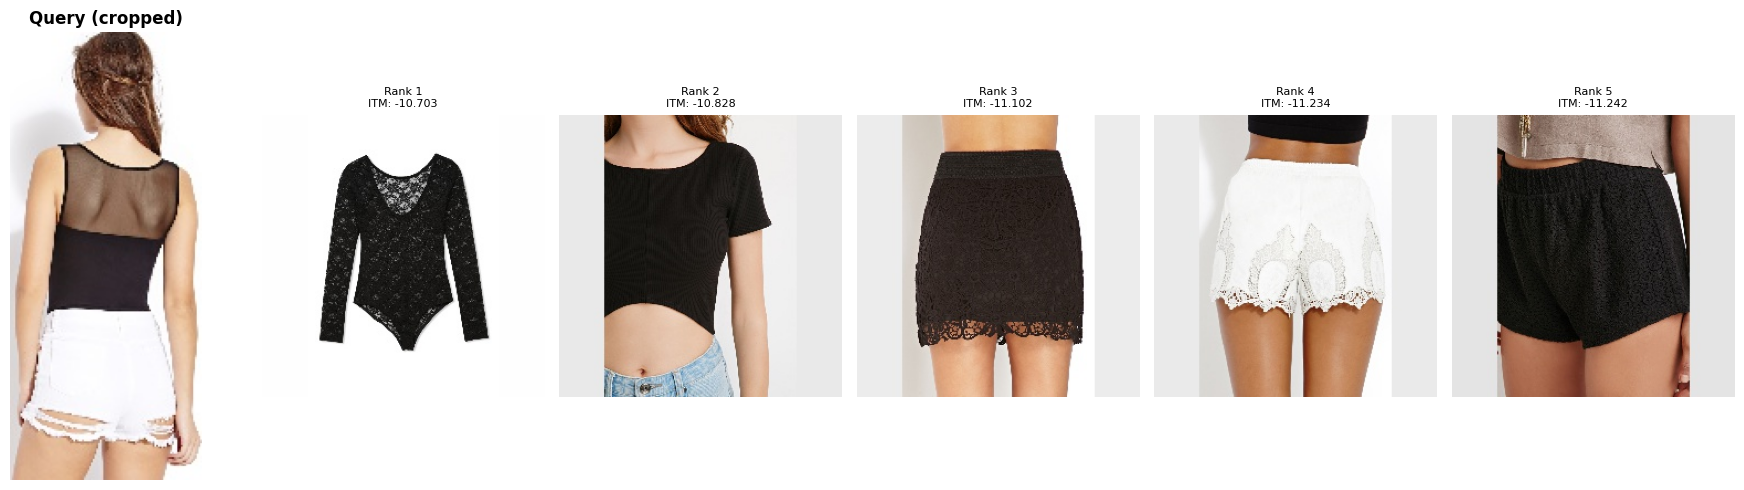


Top-5 results:
  Rank | item: id_00001492 | ITM: -10.7031 | ANN dist: 0.9887
  Rank | item: id_00007191 | ITM: -10.8281 | ANN dist: 0.9922
  Rank | item: id_00004331 | ITM: -11.1016 | ANN dist: 0.9741
  Rank | item: id_00007626 | ITM: -11.2344 | ANN dist: 0.9919
  Rank | item: id_00005150 | ITM: -11.2422 | ANN dist: 0.9927


In [7]:
query_df    = pd.read_csv('/kaggle/input/datasets/pravinkumarv45510/dataset-analysis/data/query.csv')
sample_row  = query_df.sample(1, random_state=7).iloc[0]
results     = run_query(
    query_path=sample_row['full_path'],
    top_k=FINAL_K,
    ground_truth_item=sample_row['item_id']
)
print("\nTop-5 results:")
for r in results[:5]:
    print(f"  Rank | item: {r['item_id']} | ITM: {r['itm_score']:.4f} | ANN dist: {r['ann_distance']:.4f}")

In [8]:
def ann_only_results(query_path: str, top_k: int = 10) -> list:
    raw_img   = Image.open(query_path).convert('RGB')
    cropped   = yolo_crop(raw_img)
    query_emb = encode_query(cropped)
    cand_idxs, cand_dists = retrieve_candidates(query_emb, k=top_k)
    return [
        {'item_id': gallery_item_ids[i], 'ann_distance': float(d)}
        for i, d in zip(cand_idxs, cand_dists)
    ]

ann_results = ann_only_results(sample_row['full_path'], top_k=FINAL_K)
print("ANN-only results:")
for i, r in enumerate(ann_results, 1):
    match = '✓' if r['item_id'] == sample_row['item_id'] else ' '
    print(f"  Rank {i:2d} {match} | item: {r['item_id']} | dist: {r['ann_distance']:.4f}")

ANN-only results:
  Rank  1   | item: id_00004331 | dist: 0.9741
  Rank  2   | item: id_00001492 | dist: 0.9887
  Rank  3   | item: id_00004719 | dist: 0.9890
  Rank  4   | item: id_00000543 | dist: 0.9917
  Rank  5   | item: id_00007686 | dist: 0.9918
  Rank  6   | item: id_00007626 | dist: 0.9919
  Rank  7   | item: id_00007115 | dist: 0.9920
  Rank  8   | item: id_00007191 | dist: 0.9922
  Rank  9   | item: id_00005150 | dist: 0.9927
  Rank 10   | item: id_00000629 | dist: 0.9939
